# Imports & SetUp

In [1]:
import os
import copy
import json
import math
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from PIL import Image
from pathlib import Path
from typing import Tuple
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

In [91]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, models, transforms, utils
from torch.utils.data import DataLoader, Dataset, random_split, Subset

In [64]:
import pennylane as qml
import pennylane.qnn as qnn

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [5]:
from paths_setup import TRAIN_DIR, TEST_DIR, BACKUP_DIR

if not TRAIN_DIR.exists():
    raise FileNotFoundError(f"TRAIN_DIR not found: {TRAIN_DIR}")
if not TEST_DIR.exists():
    raise FileNotFoundError(f"TEST_DIR not found: {TEST_DIR}")
if not BACKUP_DIR.exists():
    raise FileNotFoundError(f"BACKUP_DIR not found: {BACKUP_DIR}")

In [6]:
VIEW_CLASS = ["02", "06", "08", "12", "13", "14", "15", "16", "18", "21", "22", "23", "27", "30"]

missing_train = [c for c in VIEW_CLASS if not (TRAIN_DIR / c).exists()]
missing_test  = [c for c in VIEW_CLASS if not (TEST_DIR  / c).exists()]

if missing_train:
    raise FileNotFoundError(f"Missing train class folders: {missing_train}")
if missing_test:
    raise FileNotFoundError(f"Missing test class folders: {missing_test}")

In [7]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.2
NUM_WORKERS = 8

# Data Exploration

## General Information

In [9]:
def show_first_10_images(folder_dir: Path, view_name: str) -> None:
    
    view_dir = Path(folder_dir) / view_name
    png_files = sorted(view_dir.glob("*.png"))[:10]

    if not view_dir.exists():
        raise FileNotFoundError(f"Folder does not exist: {view_dir}")

    if len(png_files) == 0:
        raise FileNotFoundError(f"No PNG files found in: {view_dir}")

    n = len(png_files)
    rows, cols = 2, 5

    plt.figure(figsize=(cols * 3.2, rows * 3.2))

    for i in range(rows * cols):
        plt.subplot(rows, cols, i + 1)
        plt.axis("off")

        if i < n:
            img = Image.open(png_files[i])
            plt.imshow(img)
        else:
            plt.text(0.5, 0.5, "EMPTY", ha="center", va="center")

    plt.tight_layout()
    plt.show()

In [10]:
def count_pngs(folder: Path) -> int:
    
    if not folder.exists() or not folder.is_dir():
        return 0
    return sum(1 for p in folder.iterdir() if p.is_file() and p.suffix.lower() == ".png")

In [11]:
def print_view_image_counts(view_name: str) -> Tuple[int, int]:

    view_name = str(view_name).strip()
    
    train_view_dir = TRAIN_DIR / view_name
    test_view_dir  = TEST_DIR / view_name

    train_count = count_pngs(train_view_dir)
    test_count  = count_pngs(test_view_dir)

    return train_count, test_count

In [12]:
total_train = 0
total_test  = 0
counts_matrix = []

print(f"--- Data Summary ---")

for vc in VIEW_CLASS:
    temp_train, temp_test = print_view_image_counts(vc)

    counts_matrix.append([temp_train, temp_test])
    
    total_train += temp_train
    total_test  += temp_test
    
    print(f"View {vc}: {temp_train + temp_test} images ({temp_train} train images; {temp_test} test images)")
    
print(f"Total: {total_train + total_test} images ({total_train} train images; {total_test} test images)")

--- Data Summary ---
View 02: 19566 images (15317 train images; 4249 test images)
View 06: 10401 images (10000 train images; 401 test images)
View 08: 13020 images (10272 train images; 2748 test images)
View 12: 22663 images (18030 train images; 4633 test images)
View 13: 17814 images (14385 train images; 3429 test images)
View 14: 11139 images (10000 train images; 1139 test images)
View 15: 31473 images (25052 train images; 6421 test images)
View 16: 12061 images (10000 train images; 2061 test images)
View 18: 11058 images (10000 train images; 1058 test images)
View 21: 14059 images (11160 train images; 2899 test images)
View 22: 10895 images (10000 train images; 895 test images)
View 23: 13723 images (10930 train images; 2793 test images)
View 27: 11670 images (10000 train images; 1670 test images)
View 30: 10803 images (10000 train images; 803 test images)
Total: 210345 images (175146 train images; 35199 test images)


In [13]:
def plot_train_test_counts_stacked(view_classes: list[str], counts_matrix: list[list[int]]) -> None:
    
    if len(view_classes) != len(counts_matrix):
        raise ValueError(f"Length mismatch: view_classes - {len(view_classes)} entries, counts_matrix - {len(counts_matrix)} rows")

    train_counts = [row[0] for row in counts_matrix]
    test_counts  = [row[1] for row in counts_matrix]

    x = list(range(len(view_classes)))

    plt.figure(figsize=(max(10, len(view_classes) * 0.9), 5))

    plt.bar(x, train_counts, width=0.80, color="C0", label="Train")
    plt.bar(x, test_counts,  width=0.80, color="C1", label="Test", bottom=train_counts)

    plt.xticks(x, view_classes)
    plt.xlabel("View")
    plt.ylabel("Number of Images (Train + Test)")
    plt.title("Images per View")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [14]:
def plot_train_test_counts_overlaid(view_classes: list[str], counts_matrix: list[list[int]]) -> None:
    
    if len(view_classes) != len(counts_matrix):
        raise ValueError(f"Length mismatch: view_classes - {len(view_classes)} entries, counts_matrix - {len(counts_matrix)} rows")

    train_counts = [row[0] for row in counts_matrix]
    test_counts  = [row[1] for row in counts_matrix]

    x = list(range(len(view_classes)))
    
    plt.figure(figsize=(max(10, len(view_classes) * 0.9), 5))

    plt.bar(x, train_counts, width=0.80, color="C0", alpha=0.5, label="Train", zorder=1)
    plt.bar(x, test_counts,  width=0.80, color="C1", alpha=0.5, label="Test",  zorder=2)

    plt.xticks(x, view_classes)
    plt.xlabel("View")
    plt.ylabel("Number of Images (Train and Test - Overlaid)")
    plt.title("Images per View")
    plt.legend()
    plt.tight_layout()
    plt.show()

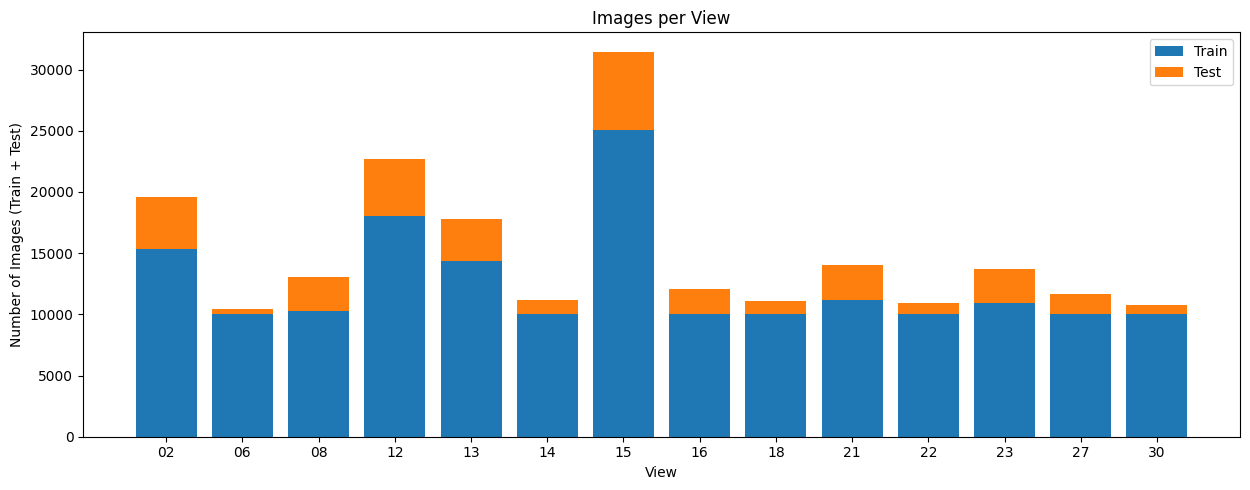

In [15]:
plot_train_test_counts_stacked(VIEW_CLASS, counts_matrix)

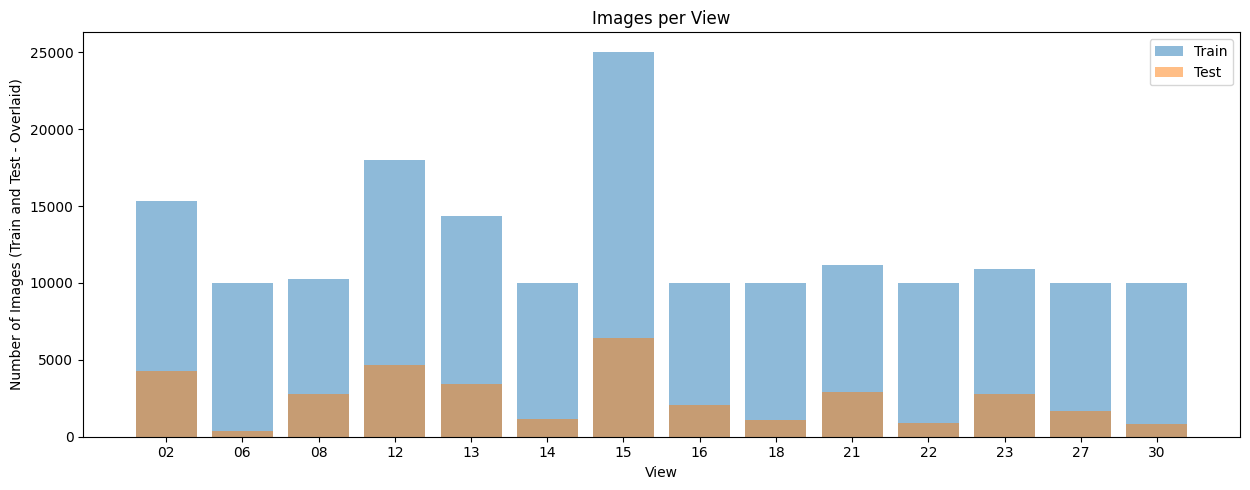

In [16]:
plot_train_test_counts_overlaid(VIEW_CLASS, counts_matrix)

## Label Mapping

In [17]:
class_to_idx = {name: i for i, name in enumerate(VIEW_CLASS)}
idx_to_class = {i: name for name, i in class_to_idx.items()}

print("Label mapping:")
for k in sorted(class_to_idx.keys()):
    print(f"   {k} -> {class_to_idx[k]}")

Label mapping:
   02 -> 0
   06 -> 1
   08 -> 2
   12 -> 3
   13 -> 4
   14 -> 5
   15 -> 6
   16 -> 7
   18 -> 8
   21 -> 9
   22 -> 10
   23 -> 11
   27 -> 12
   30 -> 13


## Check Image Size Consistency

In [18]:
EXCLUDED_FILES = []

def verify_image_dimensions(folder_dir: Path, target_size: Tuple[int, int]) -> None:
    print(f"Checking image dimensions in {folder_dir}:")
    total_mismatch = 0 
    
    for class_name in VIEW_CLASS:
        mismatch_count = 0
        
        print(f"\n   View {class_name}:")
        class_path = folder_dir / class_name
        if not class_path.exists():
            continue
            
        for img_path in class_path.glob("*.png"):
            with Image.open(img_path) as img:
                if img.size != target_size:
                    mismatch_count += 1
                    total_mismatch += 1
                    EXCLUDED_FILES.append(img_path.name)
                    print(f"      Mismatch found: {img_path.name} is {img.size}")

        if mismatch_count == 0:
            print("      No mismatches found")

    if total_mismatch == 0:
        print(f"\nSuccess: All images are confirmed to be {target_size}")
    else:
        print(f"\nWARNING: Found {total_mismatch} images with inconsistent sizes")

In [19]:
verify_image_dimensions(TRAIN_DIR, IMG_SIZE)

Checking image dimensions in /mnt/c/Users/ROG/MyProjects/Quantum/CardioQML/Dataset/View Classification/train:

   View 02:
      Mismatch found: __Amy__DicomIMG_ID_69214103__20200810140438__1.png is (432, 288)
      Mismatch found: __DCM__DicomIMG_ID_60302307__nk095938.000000__1.png is (432, 288)

   View 06:
      No mismatches found

   View 08:
      No mismatches found

   View 12:
      No mismatches found

   View 13:
      No mismatches found

   View 14:
      No mismatches found

   View 15:
      No mismatches found

   View 16:
      No mismatches found

   View 18:
      No mismatches found

   View 21:
      No mismatches found

   View 22:
      No mismatches found

   View 23:
      No mismatches found

   View 27:
      No mismatches found

   View 30:
      No mismatches found



In [20]:
verify_image_dimensions(TEST_DIR, IMG_SIZE)

Checking image dimensions in /mnt/c/Users/ROG/MyProjects/Quantum/CardioQML/Dataset/View Classification/test:

   View 02:
      No mismatches found

   View 06:
      No mismatches found

   View 08:
      No mismatches found

   View 12:
      No mismatches found

   View 13:
      No mismatches found

   View 14:
      No mismatches found

   View 15:
      No mismatches found

   View 16:
      No mismatches found

   View 18:
      No mismatches found

   View 21:
      No mismatches found

   View 22:
      No mismatches found

   View 23:
      No mismatches found

   View 27:
      No mismatches found

   View 30:
      No mismatches found

Success: All images are confirmed to be (224, 224)


In [21]:
print(f"Files to exclude: {EXCLUDED_FILES}")

Files to exclude: ['__Amy__DicomIMG_ID_69214103__20200810140438__1.png', '__DCM__DicomIMG_ID_60302307__nk095938.000000__1.png']


## View 02

In [ ]:
show_first_10_images(TRAIN_DIR, "02")
show_first_10_images(TEST_DIR,  "02")

## View 06

In [ ]:
show_first_10_images(TRAIN_DIR, "06")
show_first_10_images(TEST_DIR,  "06")

## View 08

In [ ]:
show_first_10_images(TRAIN_DIR, "08")
show_first_10_images(TEST_DIR,  "08")

## View 12

In [ ]:
show_first_10_images(TRAIN_DIR, "12")
show_first_10_images(TEST_DIR,  "12")

## View 13

In [ ]:
show_first_10_images(TRAIN_DIR, "13")
show_first_10_images(TEST_DIR,  "13")

## View 14

In [ ]:
show_first_10_images(TRAIN_DIR, "14")
show_first_10_images(TEST_DIR,  "14")

## View 15

In [ ]:
show_first_10_images(TRAIN_DIR, "15")
show_first_10_images(TEST_DIR,  "15")

## View 16

In [ ]:
show_first_10_images(TRAIN_DIR, "16")
show_first_10_images(TEST_DIR,  "16")

## View 18

In [ ]:
show_first_10_images(TRAIN_DIR, "18")
show_first_10_images(TEST_DIR,  "18")

## View 21

In [ ]:
show_first_10_images(TRAIN_DIR, "21")
show_first_10_images(TEST_DIR,  "21")

## View 22

In [ ]:
show_first_10_images(TRAIN_DIR, "22")
show_first_10_images(TEST_DIR,  "22")

## View 23

In [ ]:
show_first_10_images(TRAIN_DIR, "23")
show_first_10_images(TEST_DIR,  "23")

## View 27

In [ ]:
show_first_10_images(TRAIN_DIR, "27")
show_first_10_images(TEST_DIR,  "27")

## View 30

In [ ]:
show_first_10_images(TRAIN_DIR, "30")
show_first_10_images(TEST_DIR,  "30")

# Data Preprocessing

## Data Transforms

In [22]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ]),
    
    'val': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ]),
}

## Load & Split Data

In [23]:
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        
        if self.transform:
            x = self.transform(x)
            
        return x, y
        
    def __len__(self):
        return len(self.subset)

In [24]:
def is_valid_image(path):
    if os.path.basename(path) in EXCLUDED_FILES:
        return False 
    return path.lower().endswith('.png')

In [25]:
base_dataset = datasets.ImageFolder(root=TRAIN_DIR, is_valid_file=is_valid_image) 

train_size = int((1 - VAL_SPLIT) * len(base_dataset))
val_size = len(base_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(base_dataset, [train_size, val_size], generator=generator)

train_data = TransformedSubset(train_subset, transform=data_transforms['train'])
val_data   = TransformedSubset(val_subset,   transform=data_transforms['val'])

test_data = datasets.ImageFolder(root=TEST_DIR, is_valid_file=is_valid_image, transform=data_transforms['val'])

In [26]:
def get_counts(subset):
    targets = [subset.dataset.targets[i] for i in subset.indices]
    return np.bincount(targets, minlength=len(base_dataset.classes))

train_counts = get_counts(train_subset)
val_counts = get_counts(val_subset)
test_counts = np.bincount(test_data.targets, minlength=len(base_dataset.classes))

print(f"Dataset split (Total = {len(base_dataset) + len(test_data)}):")
for i, class_name in enumerate(base_dataset.classes):
    print(f"   View {class_name}: Train = {train_counts[i]}, Val = {val_counts[i]}, Test = {test_counts[i]}")

print("Training set size: ", len(train_data))
print("Validation set size: ", len(val_data))
print("Test set size: ", len(test_data))

Dataset split (Total = 210343):
   View 02: Train = 12276, Val = 3039, Test = 4249
   View 06: Train = 7911, Val = 2089, Test = 401
   View 08: Train = 8211, Val = 2061, Test = 2748
   View 12: Train = 14457, Val = 3573, Test = 4633
   View 13: Train = 11455, Val = 2930, Test = 3429
   View 14: Train = 8009, Val = 1991, Test = 1139
   View 15: Train = 20015, Val = 5037, Test = 6421
   View 16: Train = 7995, Val = 2005, Test = 2061
   View 18: Train = 8030, Val = 1970, Test = 1058
   View 21: Train = 8917, Val = 2243, Test = 2899
   View 22: Train = 8037, Val = 1963, Test = 895
   View 23: Train = 8771, Val = 2159, Test = 2793
   View 27: Train = 7971, Val = 2029, Test = 1670
   View 30: Train = 8060, Val = 1940, Test = 803
Training set size:  140115
Validation set size:  35029
Test set size:  35199


## Class Weights

In [27]:
base_targets = train_data.subset.dataset.targets
train_indices = train_data.subset.indices
train_targets = [base_targets[i] for i in train_indices]

class_counts = np.bincount(train_targets)
total_samples = len(train_targets)
num_classes = len(class_counts)

class_weights = total_samples / (num_classes * class_counts)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

In [28]:
print("Class weights:")
for i, class_name in enumerate(base_dataset.classes):
    print(f"   View {class_name}: Count = {class_counts[i]}, Weight = {class_weights[i]:.4f}")

Class weights:
   View 02: Count = 12276, Weight = 0.8153
   View 06: Count = 7911, Weight = 1.2651
   View 08: Count = 8211, Weight = 1.2189
   View 12: Count = 14457, Weight = 0.6923
   View 13: Count = 11455, Weight = 0.8737
   View 14: Count = 8009, Weight = 1.2496
   View 15: Count = 20015, Weight = 0.5000
   View 16: Count = 7995, Weight = 1.2518
   View 18: Count = 8030, Weight = 1.2464
   View 21: Count = 8917, Weight = 1.1224
   View 22: Count = 8037, Weight = 1.2453
   View 23: Count = 8771, Weight = 1.1411
   View 27: Count = 7971, Weight = 1.2556
   View 30: Count = 8060, Weight = 1.2417


## Data Loaders

In [29]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [ ]:
def show_batch(loader):
    images, labels = next(iter(loader))
    
    print(f"Batch shape: {images.shape}")
    
    plt.figure(figsize=(16, 8))
    
    images = images * 0.5 + 0.5 
    
    grid_img = utils.make_grid(images, nrow=8, padding=2)
    
    plt.imshow(grid_img.permute(1, 2, 0), cmap="gray")
    plt.axis('off')
    plt.title("Batch of Preprocessed Training Images (Grayscale)")
    plt.show()

show_batch(train_loader)

# Testing Models

## Utility Functions

In [31]:
num_classes = len(base_dataset.classes)

In [32]:
class_mapping_path = BACKUP_DIR / "class_mapping.json"
with open(class_mapping_path, "w") as f:
    json.dump(base_dataset.classes, f)
print(f"Saved class mapping")

Saved class mapping


In [33]:
def train_model(model_name, model, criterion, optimizer, train_loader, val_loader, num_epochs):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    best_model_wts = copy.deepcopy(model.state_dict())
    
    best_val_acc = 0.0
    best_train_acc = 0.0
    
    print(f"Starting training {model_name} model for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}:')
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())

                if epoch_acc > best_train_acc:
                    best_train_acc = epoch_acc
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        print()

    print(f'\nBest Val Acc:   {best_val_acc:.4f}')
    print(f'Best Train Acc: {best_train_acc:.4f}')
    model.load_state_dict(best_model_wts)
    return model, history

In [34]:
def plot_learning_curves(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs = range(1, len(acc) + 1)

    best_acc_epoch = np.argmax(val_acc)
    best_loss_epoch = np.argmin(val_loss)
    
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    label_acc = f'Best Acc ({val_acc[best_acc_epoch]:.4f}): Epoch {best_acc_epoch + 1}'
    plt.scatter(best_acc_epoch + 1, val_acc[best_acc_epoch], s=100, c='green', label=label_acc)
    
    plt.legend(loc='lower right')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    label_loss = f'Best Loss ({val_loss[best_loss_epoch]:.4f}): Epoch {best_loss_epoch + 1}'
    plt.scatter(best_loss_epoch + 1, val_loss[best_loss_epoch], s=100, c='red', label=label_loss)
    
    plt.legend(loc='upper right')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [35]:
def evaluate_model(model, dataloader, classes):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    
    print("--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=classes))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix')
    plt.show()

In [36]:
def save_model(trained_model, model_path, model_name):
    torch.save(trained_model.state_dict(), BACKUP_DIR / model_path)
    print(f"Saved model weights for {model_name}: {model_path}")

## K-Fold

In [61]:
def cross_validate_model(model_class, train_dataset, num_epochs, k_folds, num_workers):
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=SEED)
    
    all_targets = [s[1] for s in train_dataset.samples]
    
    splits = list(skf.split(train_dataset, all_targets))
    
    fold_accuracies = []
    
    print(f"Fold Split Distribution:")
    for fold_num, (train_idx, val_idx) in enumerate(splits):
        print(f"  Fold {fold_num+1}: {len(train_idx)} training images | {len(val_idx)} validation images")

    print(f"\nStarting K-Fold cross validation for {model_class.__name__}... ({k_folds} folds, {num_epochs} epochs each)")
    
    for fold, (train_idx, val_idx) in enumerate(splits):
        print(f"\nFOLD {fold+1}/{k_folds}")
        
        train_subset_raw = Subset(train_dataset, train_idx)
        val_subset_raw   = Subset(train_dataset, val_idx)
        
        train_data_fold = TransformedSubset(train_subset_raw, transform=data_transforms['train'])
        val_data_fold   = TransformedSubset(val_subset_raw,   transform=data_transforms['val'])
        
        train_loader = DataLoader(train_data_fold, batch_size=BATCH_SIZE, shuffle=True,  num_workers=num_workers)
        val_loader   = DataLoader(val_data_fold,   batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)
        
        model = model_class(num_classes=num_classes).to(DEVICE)
        
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        
        fold_name = f"{model_class.__name__}_Fold{fold+1}"
        fold_path = f"{fold_name}.pth"
        
        trained_model, history = train_model(
            fold_name,
            model, 
            criterion, 
            optimizer, 
            train_loader, 
            val_loader, 
            num_epochs
        )

        save_model(trained_model, fold_path, fold_name)
        
        print(f"\nEvaluating fold {fold+1} performance:")
        evaluate_model(trained_model, test_loader, train_dataset.classes)
        
        best_acc = max(history['val_acc'])
        fold_accuracies.append(best_acc)
        print(f"   Fold {fold+1} - Best Accuracy: {best_acc:.4f}")

    print(f"Cross-Validation Summary")
    print(f"Average Accuracy: {np.mean(fold_accuracies)*100:.2f}% (+/- {np.std(fold_accuracies)*100:.2f}%)")
    
    return fold_accuracies

## CNN

### Define Model

In [38]:
model_name_viewcnn = "ViewCNN"
model_path_viewcnn = f"{model_name_viewcnn}.pth"

In [39]:
class ViewCNN(nn.Module):
    def __init__(self, num_classes):
        super(ViewCNN, self).__init__()
        
        # Block 1: Input (1, 224, 224) -> Output (32, 112, 112)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 2: (32, 112, 112) -> (64, 56, 56)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Block 3: (64, 56, 56) -> (128, 28, 28)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Block 4: (128, 28, 28) -> (256, 14, 14)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.fc1 = nn.Linear(256, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.pool(self.relu(self.bn4(self.conv4(x))))

        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

### Train & Save Model

In [40]:
model_viewcnn = ViewCNN(num_classes=num_classes).to(DEVICE)

criterion_viewcnn = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_viewcnn = optim.Adam(model_viewcnn.parameters(), lr=1e-3)

num_epochs_viewcnn = 10

In [41]:
trained_model_viewcnn, history_viewcnn = train_model(model_name=model_name_viewcnn,
                                                     model=model_viewcnn,
                                                     criterion=criterion_viewcnn,
                                                     optimizer=optimizer_viewcnn,
                                                     train_loader=train_loader,
                                                     val_loader=val_loader,
                                                     num_epochs=num_epochs_viewcnn)

Starting training ViewCNN model for 10 epochs...

Epoch 1/10:
Train Loss: 1.1006 Acc: 0.5916
Val Loss: 7.9291 Acc: 0.1974


Epoch 2/10:
Train Loss: 0.4740 Acc: 0.8256
Val Loss: 2.4939 Acc: 0.4639


Epoch 3/10:
Train Loss: 0.2925 Acc: 0.8940
Val Loss: 3.6112 Acc: 0.5253


Epoch 4/10:
Train Loss: 0.2029 Acc: 0.9268
Val Loss: 1.6434 Acc: 0.6346


Epoch 5/10:
Train Loss: 0.1507 Acc: 0.9461
Val Loss: 0.5011 Acc: 0.8794


Epoch 6/10:
Train Loss: 0.1205 Acc: 0.9561
Val Loss: 1.0559 Acc: 0.8203


Epoch 7/10:
Train Loss: 0.1007 Acc: 0.9636
Val Loss: 0.2545 Acc: 0.8965


Epoch 8/10:
Train Loss: 0.0884 Acc: 0.9674
Val Loss: 0.9744 Acc: 0.7955


Epoch 9/10:
Train Loss: 0.0774 Acc: 0.9707
Val Loss: 0.4550 Acc: 0.8807


Epoch 10/10:
Train Loss: 0.0678 Acc: 0.9736
Val Loss: 0.2305 Acc: 0.9250


Best Val Acc:   0.9250
Best Train Acc: 0.9736


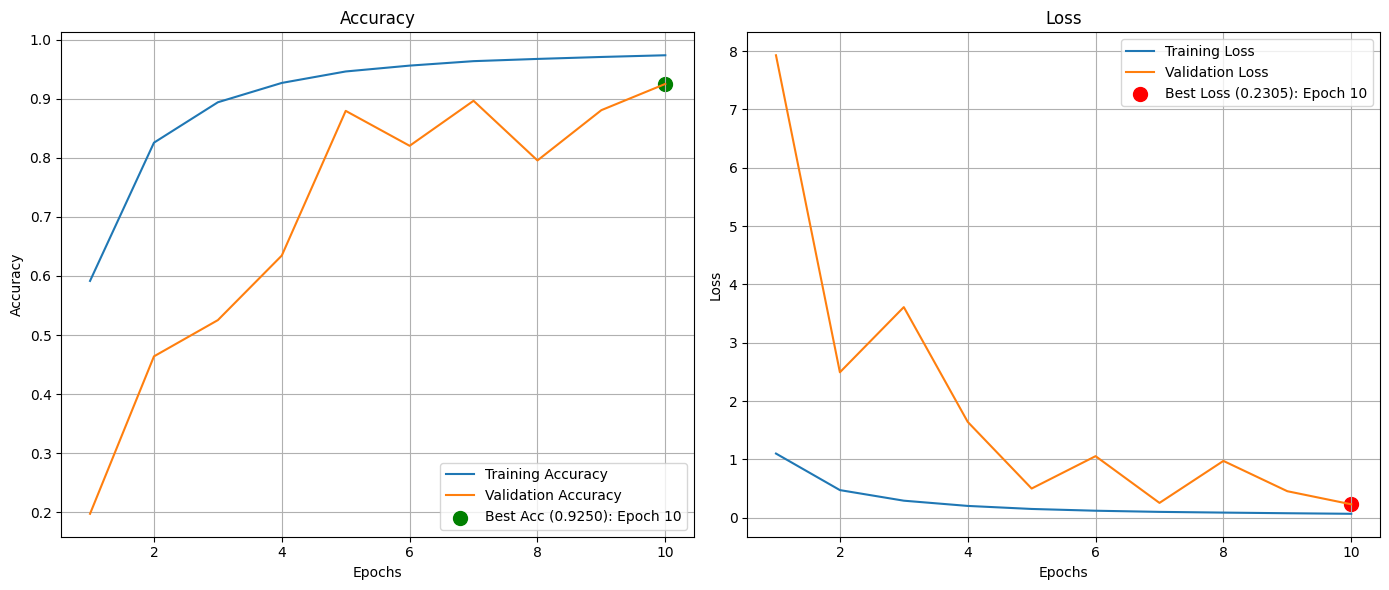

In [42]:
plot_learning_curves(history_viewcnn)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.84      0.73      0.78      4249
          06       0.00      0.00      0.00       401
          08       0.84      0.24      0.37      2748
          12       0.30      0.57      0.40      4633
          13       0.33      0.49      0.39      3429
          14       0.05      0.13      0.07      1139
          15       0.89      0.63      0.74      6421
          16       0.65      0.55      0.60      2061
          18       0.15      0.15      0.15      1058
          21       0.73      0.49      0.59      2899
          22       0.30      0.48      0.37       895
          23       0.96      0.49      0.65      2793
          27       0.93      0.75      0.83      1670
          30       0.96      0.44      0.60       803

    accuracy                           0.52     35199
   macro avg       0.57      0.44      0.47     35199
weighted avg       0.66      0.52      0.55     35

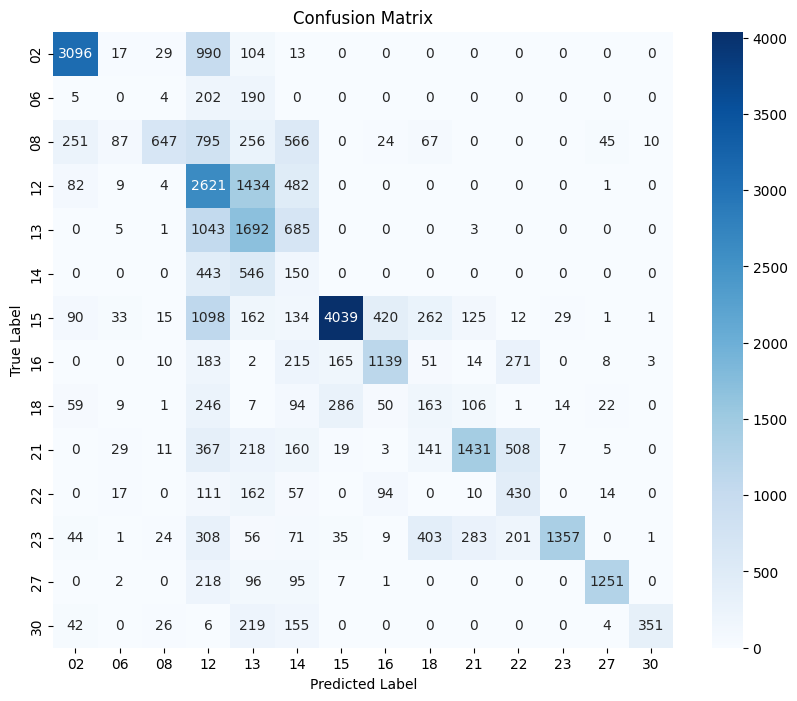

In [43]:
evaluate_model(trained_model_viewcnn, test_loader, base_dataset.classes)

In [44]:
save_model(trained_model_viewcnn, model_path_viewcnn, model_name_viewcnn)

Saved model weights for ViewCNN: ViewCNN.pth


### Load & Check Model

In [45]:
loaded_model_viewcnn = ViewCNN(num_classes=num_classes).to(DEVICE)

In [46]:
if not os.path.exists(BACKUP_DIR / model_path_viewcnn):
    raise FileNotFoundError(f"Model file not found: {model_path_viewcnn}")

In [ ]:
loaded_model_viewcnn.load_state_dict(torch.load(BACKUP_DIR / model_path_viewcnn))
loaded_model_viewcnn.eval()
evaluate_model(loaded_model_viewcnn, test_loader, base_dataset.classes)

## ResNet

### Define Model

In [47]:
model_name_viewresnet = "ViewResNet"
model_path_viewresnet = f"{model_name_viewresnet}.pth"

In [48]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        
        # First convolution
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # Second convolution
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)

        return out

class ViewResNet(nn.Module):
    def __init__(self, num_classes, in_channels=1):
        super(ViewResNet, self).__init__()
        
        # Initial Convolution
        self.in_channels = 64
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # ResNet Layers
        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)
        self.layer4 = self._make_layer(512, blocks=2, stride=2)

        # Classification Head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None
        
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        layers.append(ResidualBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        # Initial processing
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Residual Layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Output Head
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

### Train & Save Model

In [49]:
model_viewresnet = ViewResNet(num_classes=num_classes).to(DEVICE)

criterion_viewresnet = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_viewresnet = optim.Adam(model_viewresnet.parameters(), lr=1e-3)

num_epochs_viewresnet = 10

In [50]:
trained_model_viewresnet, history_viewresnet = train_model(model_name=model_name_viewresnet,
                                                           model=model_viewresnet,
                                                           criterion=criterion_viewresnet,
                                                           optimizer=optimizer_viewresnet,
                                                           train_loader=train_loader,
                                                           val_loader=val_loader,
                                                           num_epochs=num_epochs_viewresnet)

Starting training ViewResNet model for 10 epochs...

Epoch 1/10:
Train Loss: 0.2667 Acc: 0.9013
Val Loss: 3.3300 Acc: 0.6225


Epoch 2/10:
Train Loss: 0.0515 Acc: 0.9800
Val Loss: 0.0407 Acc: 0.9816


Epoch 3/10:
Train Loss: 0.0342 Acc: 0.9838
Val Loss: 0.0275 Acc: 0.9846


Epoch 4/10:
Train Loss: 0.0259 Acc: 0.9864
Val Loss: 0.0206 Acc: 0.9872


Epoch 5/10:
Train Loss: 0.0233 Acc: 0.9868
Val Loss: 0.0220 Acc: 0.9869


Epoch 6/10:
Train Loss: 0.0206 Acc: 0.9879
Val Loss: 0.0201 Acc: 0.9886


Epoch 7/10:
Train Loss: 0.0184 Acc: 0.9889
Val Loss: 0.0131 Acc: 0.9897


Epoch 8/10:
Train Loss: 0.0172 Acc: 0.9892
Val Loss: 0.0188 Acc: 0.9890


Epoch 9/10:
Train Loss: 0.0176 Acc: 0.9890
Val Loss: 0.0157 Acc: 0.9900


Epoch 10/10:
Train Loss: 0.0159 Acc: 0.9894
Val Loss: 0.0151 Acc: 0.9907


Best Val Acc:   0.9907
Best Train Acc: 0.9894


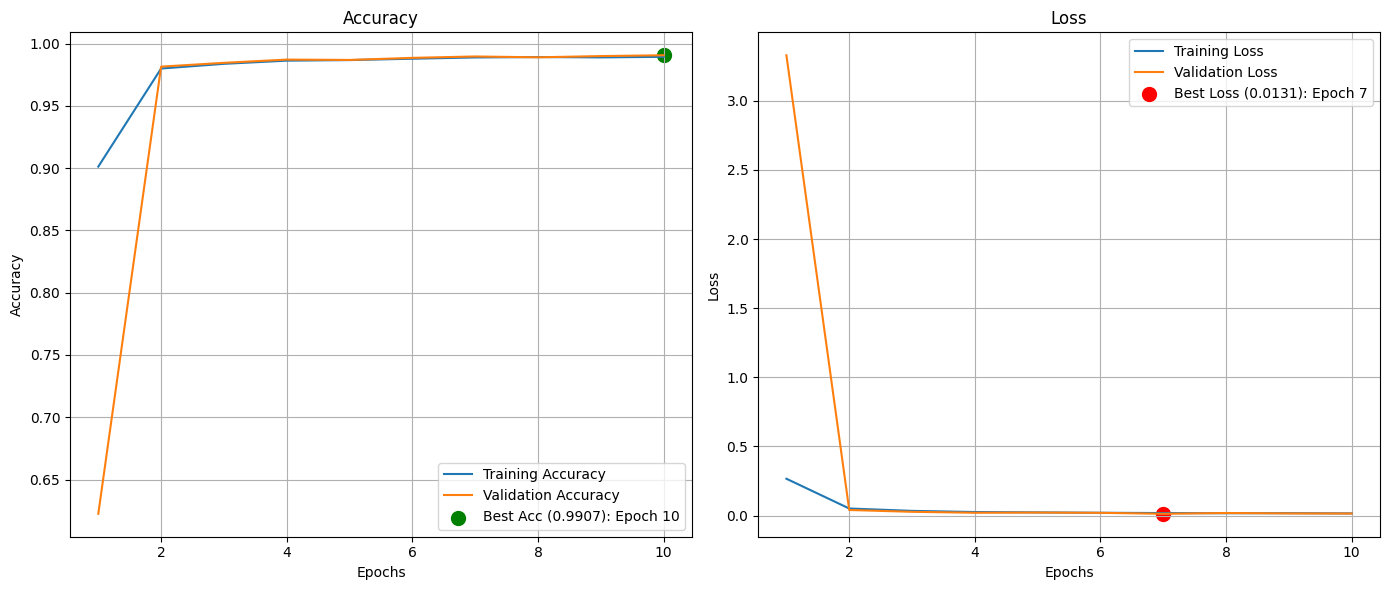

In [51]:
plot_learning_curves(history_viewresnet)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.92      0.96      0.94      4249
          06       0.25      0.13      0.17       401
          08       0.83      0.83      0.83      2748
          12       0.67      0.56      0.61      4633
          13       0.47      0.69      0.56      3429
          14       0.16      0.05      0.07      1139
          15       0.87      0.91      0.89      6421
          16       0.73      0.52      0.61      2061
          18       0.60      0.79      0.68      1058
          21       0.83      0.79      0.81      2899
          22       0.55      0.29      0.38       895
          23       0.76      0.91      0.83      2793
          27       0.98      0.90      0.94      1670
          30       0.89      0.92      0.91       803

    accuracy                           0.75     35199
   macro avg       0.68      0.66      0.66     35199
weighted avg       0.75      0.75      0.74     35

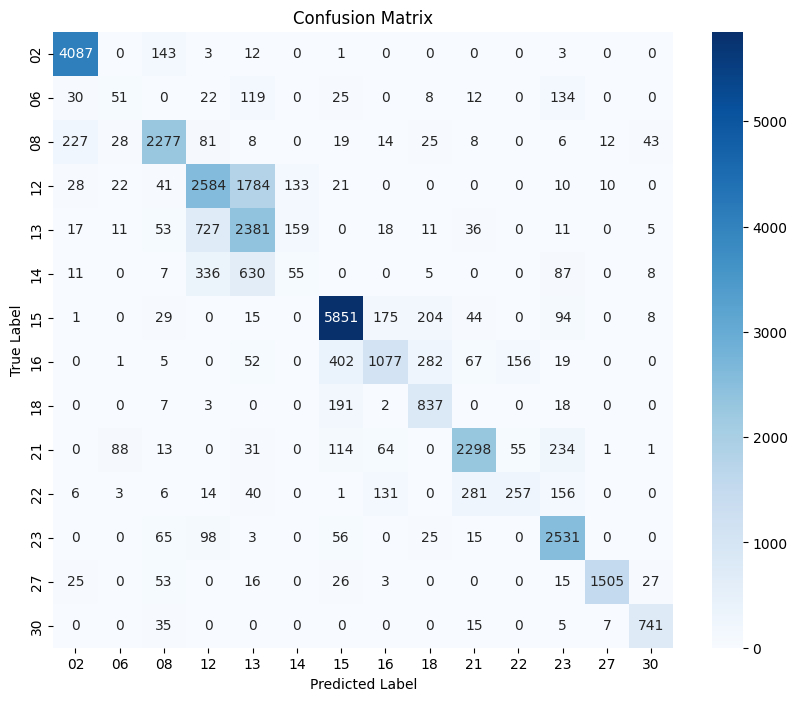

In [52]:
evaluate_model(trained_model_viewresnet, test_loader, base_dataset.classes)

In [53]:
save_model(trained_model_viewresnet, model_path_viewresnet, model_name_viewresnet)

Saved model weights for ViewResNet: ViewResNet.pth


### Load & Check Model

In [54]:
loaded_model_viewresnet = ViewResNet(num_classes=num_classes).to(DEVICE)

In [55]:
if not os.path.exists(BACKUP_DIR / model_path_viewresnet):
    raise FileNotFoundError(f"Model file not found: {model_path_viewresnet}")

In [ ]:
loaded_model_viewresnet.load_state_dict(torch.load(BACKUP_DIR / model_path_viewresnet))
loaded_model_viewresnet.eval()
evaluate_model(loaded_model_viewresnet, test_loader, base_dataset.classes)

## ResNet (KFold)

In [ ]:
cv_results = cross_validate_model(
    model_class=ViewResNet,
    train_dataset=base_dataset,
    num_epochs=10,
    k_folds=5,
    num_workers=NUM_WORKERS
)

Classification Report for all Folds:
   FOLD 1:
--- Classification Report ---
              precision    recall  f1-score   support

          02       0.90      0.88      0.89      4249
          06       0.84      0.15      0.26       401
          08       0.78      0.77      0.78      2748
          12       0.55      0.79      0.65      4633
          13       0.49      0.39      0.43      3429
          14       0.48      0.14      0.22      1139
          15       0.86      0.91      0.88      6421
          16       0.73      0.67      0.70      2061
          18       0.73      0.79      0.76      1058
          21       0.77      0.85      0.81      2899
          22       0.68      0.27      0.38       895
          23       0.89      0.83      0.86      2793
          27       0.86      0.90      0.88      1670
          30       0.97      0.87      0.92       803

    accuracy                           0.75     35199
   macro avg       0.75      0.66      0.67     35199
we

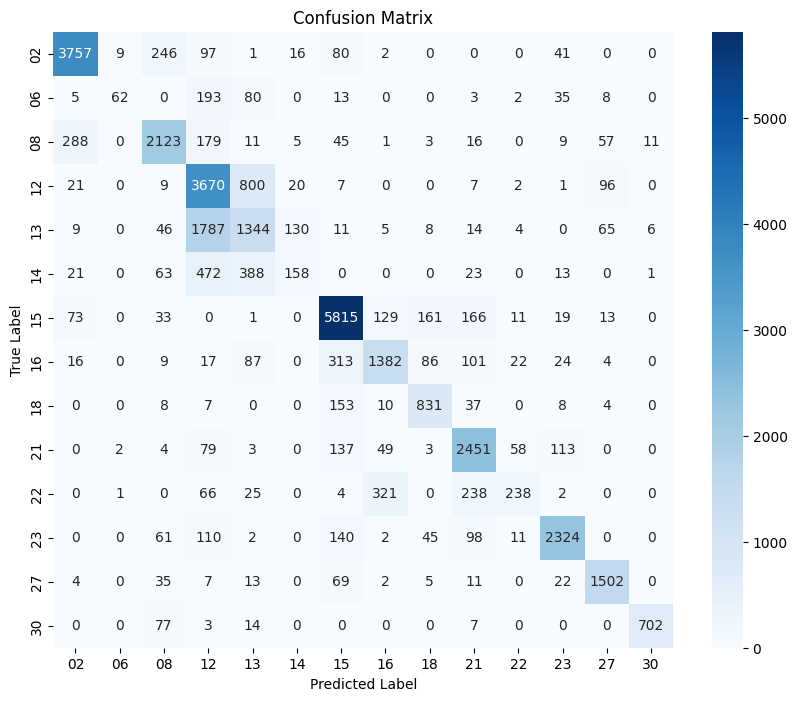

   FOLD 2:
--- Classification Report ---
              precision    recall  f1-score   support

          02       0.93      0.91      0.92      4249
          06       0.88      0.52      0.65       401
          08       0.80      0.89      0.84      2748
          12       0.62      0.66      0.64      4633
          13       0.49      0.51      0.50      3429
          14       0.30      0.19      0.23      1139
          15       0.88      0.89      0.89      6421
          16       0.73      0.71      0.72      2061
          18       0.67      0.79      0.73      1058
          21       0.83      0.76      0.79      2899
          22       0.57      0.44      0.50       895
          23       0.85      0.88      0.87      2793
          27       0.89      0.92      0.91      1670
          30       0.98      0.96      0.97       803

    accuracy                           0.77     35199
   macro avg       0.74      0.72      0.73     35199
weighted avg       0.76      0.77      

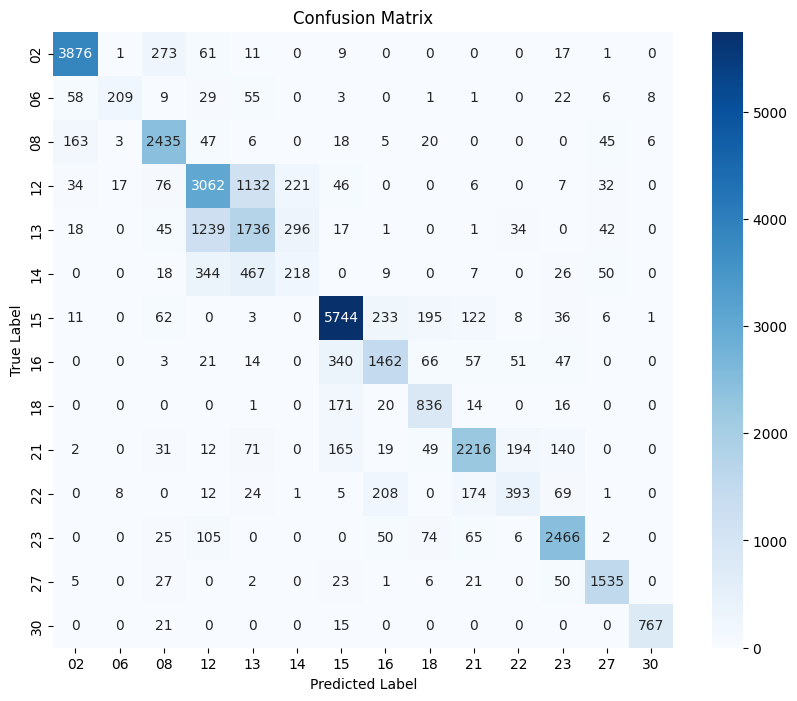

   FOLD 3:
--- Classification Report ---
              precision    recall  f1-score   support

          02       0.91      0.95      0.93      4249
          06       0.81      0.29      0.42       401
          08       0.77      0.89      0.82      2748
          12       0.63      0.63      0.63      4633
          13       0.48      0.60      0.54      3429
          14       0.29      0.08      0.13      1139
          15       0.89      0.86      0.87      6421
          16       0.72      0.67      0.69      2061
          18       0.69      0.85      0.76      1058
          21       0.80      0.75      0.78      2899
          22       0.60      0.47      0.53       895
          23       0.85      0.91      0.88      2793
          27       0.96      0.92      0.94      1670
          30       0.91      0.85      0.88       803

    accuracy                           0.76     35199
   macro avg       0.74      0.69      0.70     35199
weighted avg       0.76      0.76      

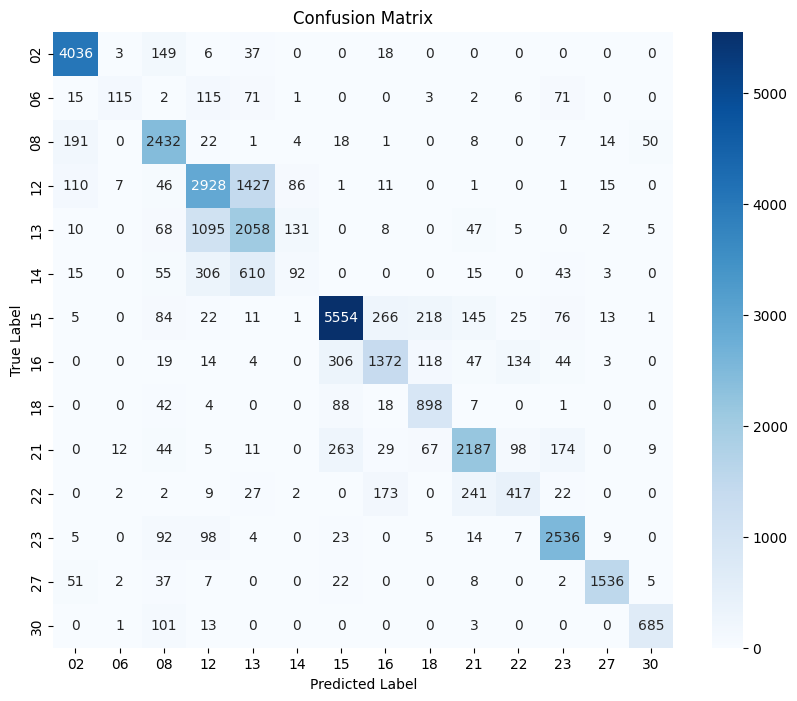

   FOLD 4:
--- Classification Report ---
              precision    recall  f1-score   support

          02       0.96      0.90      0.93      4249
          06       0.85      0.13      0.22       401
          08       0.85      0.86      0.85      2748
          12       0.61      0.68      0.64      4633
          13       0.47      0.56      0.51      3429
          14       0.46      0.13      0.20      1139
          15       0.85      0.93      0.89      6421
          16       0.77      0.73      0.75      2061
          18       0.85      0.65      0.74      1058
          21       0.79      0.81      0.80      2899
          22       0.66      0.47      0.55       895
          23       0.82      0.90      0.86      2793
          27       0.90      0.90      0.90      1670
          30       0.94      0.89      0.92       803

    accuracy                           0.77     35199
   macro avg       0.77      0.68      0.70     35199
weighted avg       0.77      0.77      

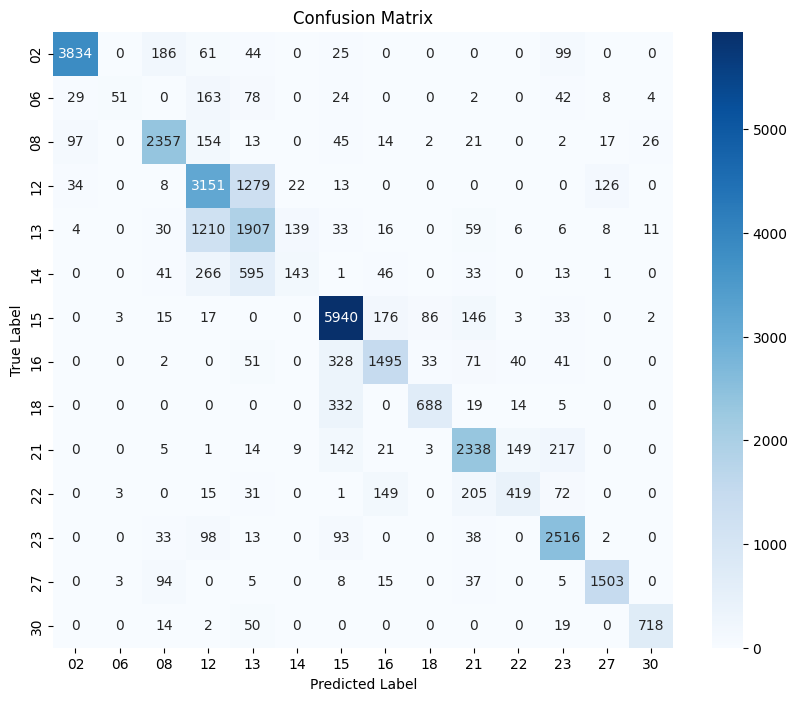

   FOLD 5:
--- Classification Report ---
              precision    recall  f1-score   support

          02       0.93      0.95      0.94      4249
          06       0.74      0.20      0.32       401
          08       0.82      0.85      0.83      2748
          12       0.58      0.68      0.63      4633
          13       0.41      0.48      0.44      3429
          14       0.35      0.10      0.15      1139
          15       0.84      0.91      0.87      6421
          16       0.83      0.63      0.71      2061
          18       0.80      0.45      0.57      1058
          21       0.74      0.86      0.80      2899
          22       0.60      0.54      0.57       895
          23       0.85      0.88      0.87      2793
          27       0.93      0.86      0.89      1670
          30       0.92      0.70      0.79       803

    accuracy                           0.75     35199
   macro avg       0.74      0.65      0.67     35199
weighted avg       0.75      0.75      

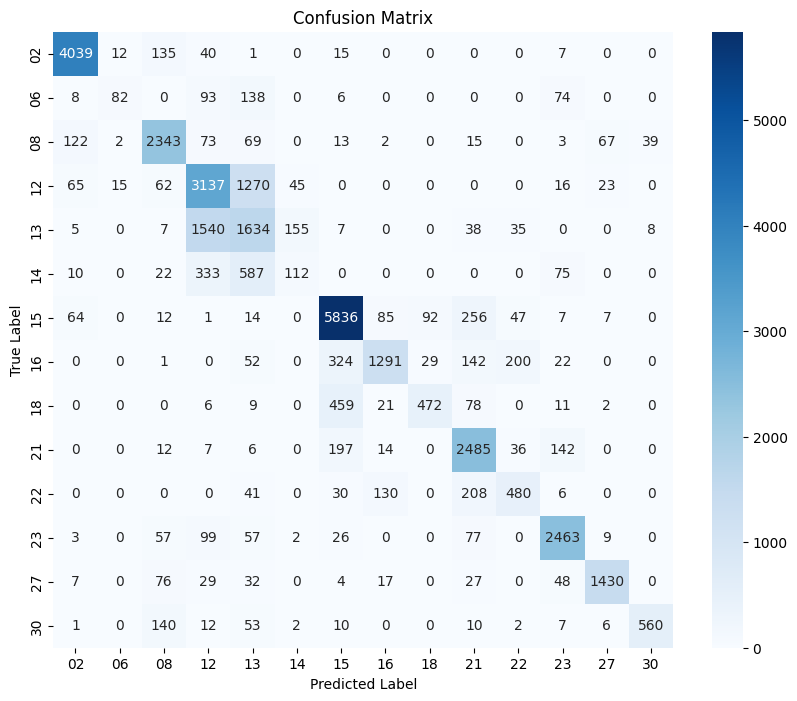

In [63]:
print("Classification Report for all Folds:")
for i in range(5):
    loaded_model_fold = ViewResNet(num_classes=num_classes).to(DEVICE)
    model_path_fold = f"ViewResNet_Fold{i+1}.pth"

    if not os.path.exists(BACKUP_DIR / model_path_fold):
        raise FileNotFoundError(f"Model file not found: {model_path_fold}")

    print(f"   FOLD {i+1}:")
    loaded_model_fold.load_state_dict(torch.load(BACKUP_DIR / model_path_fold))
    loaded_model_fold.eval()
    evaluate_model(loaded_model_fold, test_loader, base_dataset.classes)

## Quantum Neural Network (Hybrid)

### Define Model

In [81]:
n_qubits_qnn = 4
n_layers_qnn = 2

In [82]:
model_name_qnn = "HybridQNN"
model_path_qnn = f"{model_name_qnn}.pth"

In [83]:
quantum_dev = qml.device('default.qubit', wires=n_qubits_qnn)

@qml.qnode(quantum_dev, interface='torch')
def quantum_circuit(inputs, weights):
    qml.templates.AngleEmbedding(inputs, wires=range(n_qubits_qnn))
    
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits_qnn))
    
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits_qnn)]
    
weight_shapes = {"weights": (n_layers_qnn, n_qubits_qnn, 3)}

qlayer = qnn.TorchLayer(quantum_circuit, weight_shapes)

In [84]:
class HybridQNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.fc1 = nn.Linear(32, n_qubits_qnn)
        self.qlayer = qlayer
        self.fc2 = nn.Linear(n_qubits_qnn, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = torch.tanh(x) * math.pi
        x = self.qlayer(x)
        x = self.fc2(x)
        return x

### Train & Save Model

In [85]:
model_qnn = HybridQNN(num_classes=num_classes).to(DEVICE)

criterion_qnn = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_qnn = optim.Adam(model_qnn.parameters(), lr=1e-3)

num_epochs_qnn = 10

In [86]:
trained_model_qnn, history_qnn = train_model(model_name=model_name_qnn,
                                             model=model_qnn,
                                             criterion=criterion_qnn,
                                             optimizer=optimizer_qnn,
                                             train_loader=train_loader,
                                             val_loader=val_loader,
                                             num_epochs=num_epochs_qnn)

Starting training HybridQNN model for 10 epochs...

Epoch 1/10:
Train Loss: 2.3860 Acc: 0.1478
Val Loss: 2.2616 Acc: 0.1842


Epoch 2/10:
Train Loss: 2.1961 Acc: 0.2108
Val Loss: 2.1325 Acc: 0.2554


Epoch 3/10:
Train Loss: 1.9903 Acc: 0.2902
Val Loss: 1.8430 Acc: 0.3094


Epoch 4/10:
Train Loss: 1.7566 Acc: 0.3275
Val Loss: 1.8080 Acc: 0.3109


Epoch 5/10:
Train Loss: 1.6583 Acc: 0.3527
Val Loss: 1.6446 Acc: 0.3570


Epoch 6/10:
Train Loss: 1.5952 Acc: 0.3825
Val Loss: 1.6397 Acc: 0.3473


Epoch 7/10:
Train Loss: 1.5379 Acc: 0.4138
Val Loss: 1.4741 Acc: 0.4365


Epoch 8/10:
Train Loss: 1.4786 Acc: 0.4436
Val Loss: 1.5146 Acc: 0.4282


Epoch 9/10:
Train Loss: 1.4265 Acc: 0.4698
Val Loss: 1.3686 Acc: 0.4960


Epoch 10/10:
Train Loss: 1.3736 Acc: 0.4902
Val Loss: 1.3451 Acc: 0.4966


Best Val Acc:   0.4966
Best Train Acc: 0.4902


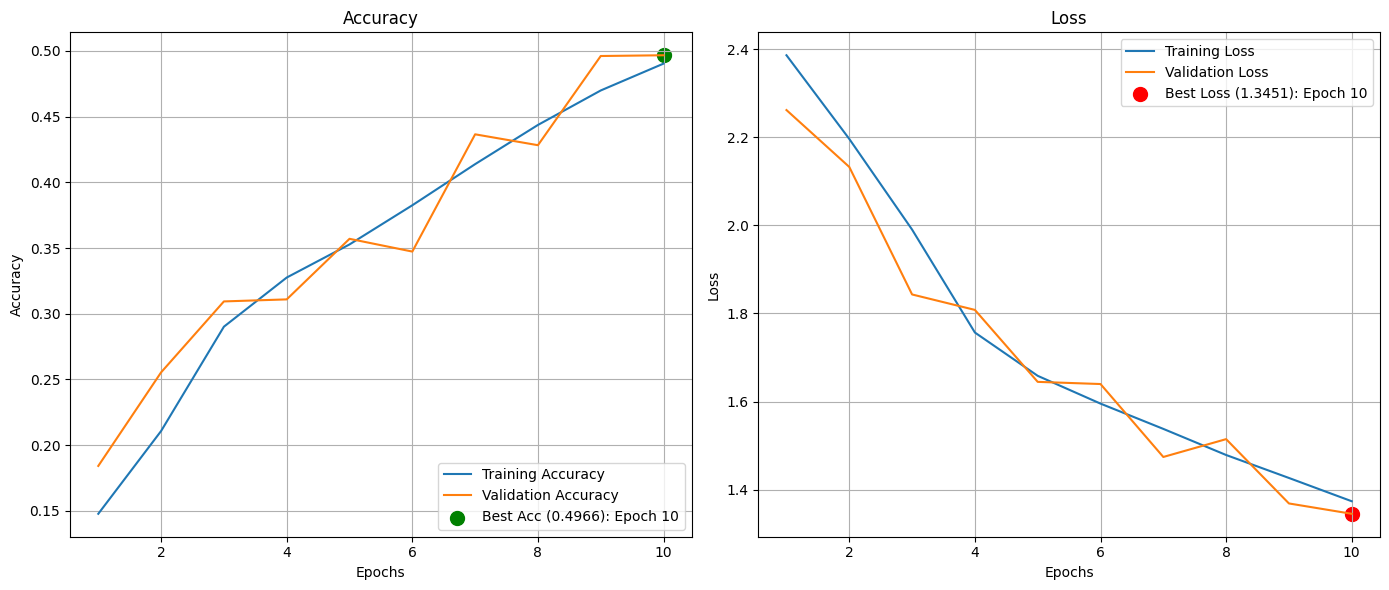

In [87]:
plot_learning_curves(history_qnn)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.69      0.64      0.66      4249
          06       0.00      0.00      0.00       401
          08       0.26      0.47      0.34      2748
          12       0.36      0.12      0.18      4633
          13       0.30      0.50      0.37      3429
          14       0.01      0.01      0.01      1139
          15       0.61      0.66      0.63      6421
          16       0.79      0.12      0.21      2061
          18       0.07      0.17      0.10      1058
          21       0.29      0.37      0.32      2899
          22       0.52      0.15      0.23       895
          23       0.43      0.51      0.47      2793
          27       0.67      0.15      0.25      1670
          30       0.00      0.00      0.00       803

    accuracy                           0.39     35199
   macro avg       0.36      0.28      0.27     35199
weighted avg       0.44      0.39      0.38     35

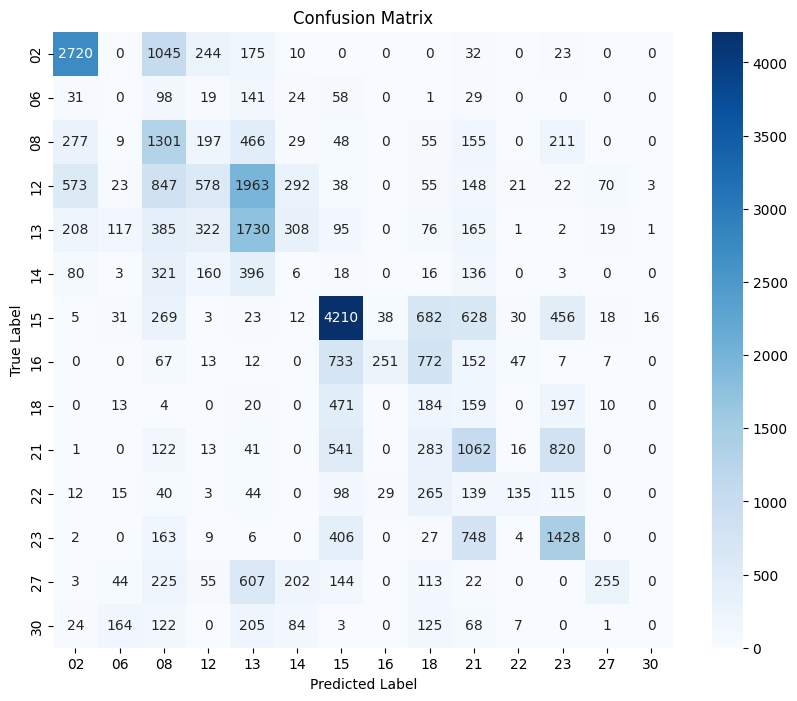

In [88]:
evaluate_model(trained_model_qnn, test_loader, base_dataset.classes)

In [89]:
save_model(trained_model_qnn, model_path_qnn, model_name_qnn)

Saved model weights for HybridQNN: HybridQNN.pth


### Load & Check Model

In [92]:
loaded_model_qnn = HybridQNN(num_classes=num_classes).to(DEVICE)

In [93]:
if not os.path.exists(BACKUP_DIR / model_path_qnn):
    raise FileNotFoundError(f"Model file not found: {model_path_qnn}")

In [ ]:
loaded_model_qnn.load_state_dict(torch.load(BACKUP_DIR / model_path_qnn))
loaded_model_qnn.eval()
evaluate_model(loaded_model_qnn, test_loader, base_dataset.classes)

## Hybrid ResNet + Quantum Head

### Define Model

In [94]:
n_qubits_qresnet = 4
n_layers_qresnet = 2

In [95]:
model_name_qresnet = "ResNetQuantumHead"
model_path_qresnet = f"{model_name_qresnet}.pth"

In [96]:
dev_qresnet = qml.device('default.qubit', wires=n_qubits_qresnet)

@qml.qnode(dev_qresnet, interface='torch')
def quantum_circuit_qresnet(inputs, weights):

    qml.templates.AngleEmbedding(inputs, wires=range(n_qubits_qresnet))

    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits_qresnet))

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits_qresnet)]
    
weight_shapes_qresnet = {'weights': (n_layers_qresnet, n_qubits_qresnet, 3)}

qlayer_qresnet = qnn.TorchLayer(quantum_circuit_qresnet, weight_shapes_qresnet)

In [97]:
class ResNetQuantumHead(nn.Module):
    def __init__(self, base_model, num_classes):
        super().__init__()
        self.base = base_model
        in_features = self.base.fc.in_features
        self.base.fc = nn.Identity()
        self.fc1 = nn.Linear(in_features, n_qubits_qresnet)
        self.q_layer = qlayer_qresnet
        self.fc_out = nn.Linear(n_qubits_qresnet, num_classes)

    def forward(self, x):
        x = self.base(x)
        x = self.fc1(x)
        x = torch.tanh(x) * math.pi
        x = self.q_layer(x)
        x = self.fc_out(x)
        return x

In [99]:
backbone = models.resnet18(weights=None)
backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

### Train & Save Model

In [100]:
model_qresnet = ResNetQuantumHead(base_model=backbone, num_classes=num_classes).to(DEVICE)

criterion_qresnet = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_qresnet = optim.Adam(model_qresnet.parameters(), lr=1e-3)

num_epochs_qresnet = 10

In [101]:
trained_model_qresnet, history_qresnet = train_model(model_name=model_name_qresnet,
                                                     model=model_qresnet,
                                                     criterion=criterion_qresnet,
                                                     optimizer=optimizer_qresnet,
                                                     train_loader=train_loader,
                                                     val_loader=val_loader,
                                                     num_epochs=num_epochs_qresnet)

Starting training ResNetQuantumHead model for 10 epochs...

Epoch 1/10:
Train Loss: 2.4424 Acc: 0.1398
Val Loss: 1.8761 Acc: 0.2910


Epoch 2/10:
Train Loss: 1.3566 Acc: 0.5120
Val Loss: 1.0144 Acc: 0.6012


Epoch 3/10:
Train Loss: 0.8759 Acc: 0.6582
Val Loss: 0.7634 Acc: 0.7057


Epoch 4/10:
Train Loss: 0.7400 Acc: 0.7039
Val Loss: 0.6745 Acc: 0.7329


Epoch 5/10:
Train Loss: 0.6420 Acc: 0.7418
Val Loss: 0.5352 Acc: 0.8610


Epoch 6/10:
Train Loss: 0.3923 Acc: 0.9328
Val Loss: 0.2588 Acc: 0.9836


Epoch 7/10:
Train Loss: 0.2149 Acc: 0.9835
Val Loss: 0.1467 Acc: 0.9884


Epoch 8/10:
Train Loss: 0.1227 Acc: 0.9867
Val Loss: 0.1239 Acc: 0.9788


Epoch 9/10:
Train Loss: 0.0773 Acc: 0.9870
Val Loss: 0.0529 Acc: 0.9891


Epoch 10/10:
Train Loss: 0.0544 Acc: 0.9876
Val Loss: 0.0442 Acc: 0.9879


Best Val Acc:   0.9891
Best Train Acc: 0.9876


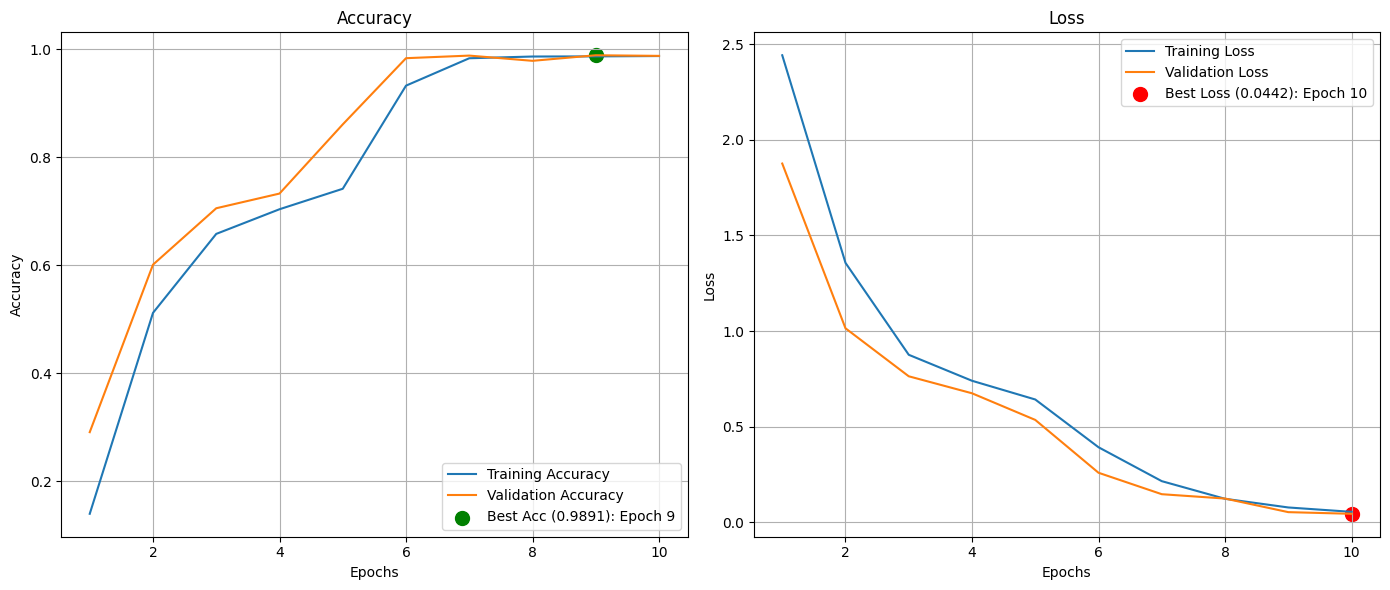

In [102]:
plot_learning_curves(history_qresnet)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.91      0.89      0.90      4249
          06       0.42      0.35      0.38       401
          08       0.79      0.84      0.81      2748
          12       0.59      0.60      0.59      4633
          13       0.45      0.51      0.48      3429
          14       0.34      0.09      0.15      1139
          15       0.91      0.77      0.83      6421
          16       0.50      0.78      0.61      2061
          18       0.50      0.53      0.52      1058
          21       0.70      0.74      0.72      2899
          22       0.84      0.42      0.56       895
          23       0.77      0.74      0.75      2793
          27       0.66      0.93      0.77      1670
          30       1.00      0.67      0.80       803

    accuracy                           0.70     35199
   macro avg       0.67      0.63      0.63     35199
weighted avg       0.71      0.70      0.70     35

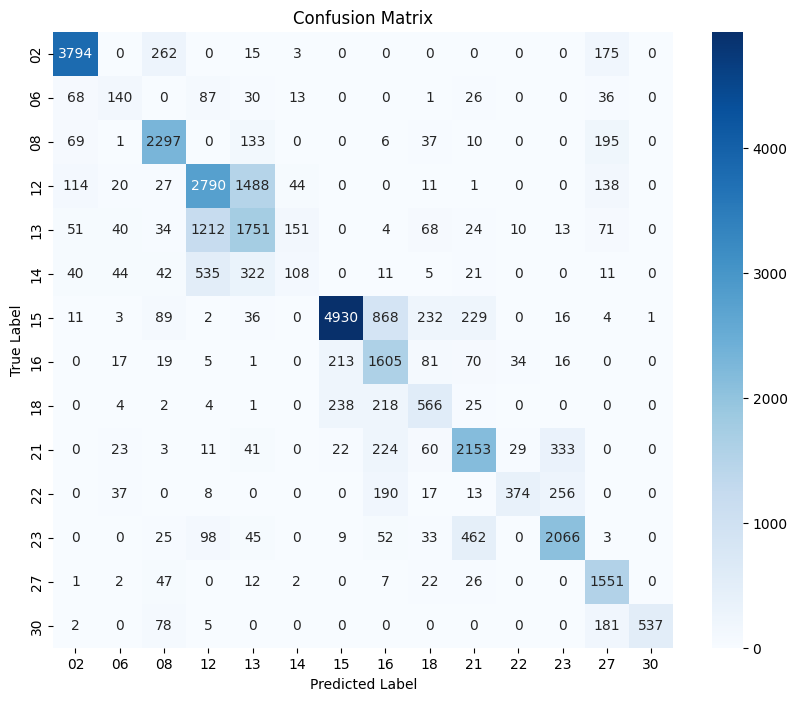

In [103]:
evaluate_model(trained_model_qresnet, test_loader, base_dataset.classes)

In [104]:
save_model(trained_model_qresnet, model_path_qresnet, model_name_qresnet)

Saved model weights for ResNetQuantumHead: ResNetQuantumHead.pth
